**##Assignment: Comparative Study — Multi-Class Wine Quality Classification**

Importing all required libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

In [7]:
from google.colab import files
uploaded=files.upload()

Saving winequality-red.csv to winequality-red.csv
Saving winequality-white.csv to winequality-white.csv


Reading the dataset to dataframes

**Task 1 — Load & Inspect the Data (Red + White)**

In [8]:
red = pd.read_csv("winequality-red.csv", sep=";")
white = pd.read_csv("winequality-white.csv", sep=";")

In [9]:
red.shape

(1599, 12)

In [10]:
red.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [11]:
red.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [12]:
white.shape

(4898, 12)

In [13]:
white.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [14]:
white.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

After initial investigation,
1. Both the data sets are loaded correctly into red and white dataframe.
2. Red dataframe has 1599 rows and 12 columns, white has 4898 rows and 12 columns.
3. The target column' Quality exists in both dataframes.
4. All features are numeric for both data sets


**Task 2 — Data Quality Checks + Class Distribution (Comparative)**

Task 2.1.1

Checking for missing values of red data set

In [15]:
red.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [16]:
red.duplicated().sum()

np.int64(240)

Task 2.1.2

Dropping the duplicated rows of red dataframe

In [17]:
red.drop_duplicates(inplace=True)

In [18]:
red.duplicated().sum()

np.int64(0)

Task 2.2.1

Checking missing values for white dataframe

In [19]:
white.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [20]:
white.duplicated().sum()

np.int64(937)

Task 2.2.2

Dropping the duplicated rows of white dataframe

In [21]:
white.drop_duplicates(inplace=True)

In [22]:
white.duplicated().sum()

np.int64(0)

When we checked for missing values for both data sets, it was found that there are no missing vales for both.Hence imputation was not necessary

When we chack for duplicated rows, the red data contains 240 duplicate rows and white data set contains 937 duplicate rows

We have dropped the duplicate rows from both data sets and cleaned it for further EDA process. Since all features were numeric in nature there were no need of any conversions like category or dates

Task 2.3

Class Distribution of Quality

In [23]:
#2.3.1 Total counts for red wine
red['quality'].value_counts()

,count
quality,
5,577
6,535
7,167
4,53
8,17
3,10


In [24]:
#2.3.2 percentage for red wine
(red['quality'].value_counts(normalize=True)*100).round(2)

,proportion
quality,
5,42.46
6,39.37
7,12.29
4,3.90
8,1.25
3,0.74


In [25]:
#2.3.1 Total counts for white wine
white['quality'].value_counts()

,count
quality,
6,1788
5,1175
7,689
4,153
8,131
3,20
9,5


In [26]:
#2.3.2 percentage of white wine
(white['quality'].value_counts(normalize=True)*100).round(2)

,proportion
quality,
6,45.14
5,29.66
7,17.39
4,3.86
8,3.31
3,0.50
9,0.13


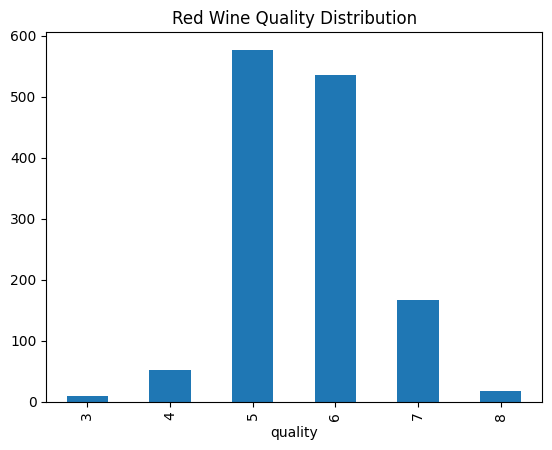

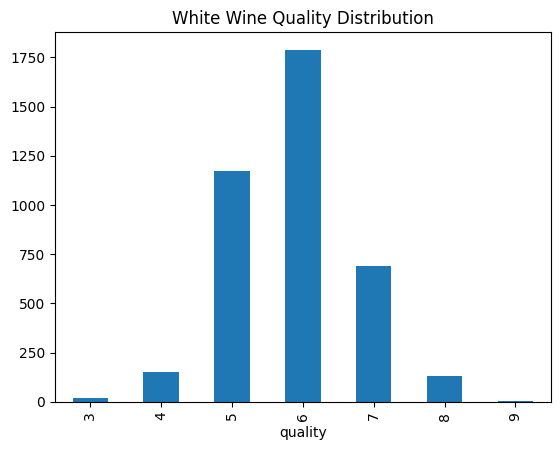

In [27]:
# 2.4 plotting for white wine and red wine

plt.figure()
red['quality'].value_counts().sort_index().plot(kind='bar')
plt.title("Red Wine Quality Distribution")
plt.show()

plt.figure()
white['quality'].value_counts().sort_index().plot(kind='bar')
plt.title("White Wine Quality Distribution")
plt.show()

Task 2

● Which dataset is more imbalanced?

The red wine data set is more imbalanced as the no of samples in red wine is

more concentrated towards quality 5 and 6 when compared to white wine data set

and there are very few samples in 3, 4, 7, 8

The distribution is heavily skewed toward middle values

In contrast, the white wine dataset, although still centered around 5 to 7, has

more data regarding samples and slightly better spread across classes.So relative imbalance is worse in red wine.

● Which quality classes are rare?

In red wine data set, quality 3 and 8 are very rare with counts 10 and 17 respectvely, quality 4 also seem to be rare. Quality 7 is also less frequent but no of samples with quality 5 and 6 seems to be huge.

In white wine data set, quality 9 is extremeley rare and sample are negligible, follwed by quality 3 and 4. The samples of quality 5,6 and 7 are not so rare.

● Why might rare classes be harder to predict?

There are no much samples of rare classes to test and train, so prediction with less samples will not be reliable.

Model overfits less samples, that is learning becomes too specific it will gives specific details, generalization will be with too specific details.

When a model overfits on rare classes, it memorizes the limited training examples instead of learning general patterns. This leads to high training accuracy but poor performance on new data. The model is highly sensitive to noise, where even a few incorrect samples can distort learning. As a result, it shows poor recall for the rare class, either misclassifying it or predicting it only under very strict conditions.

**Task 3 — Prepare Data for Modeling (Same Setup for Fair Comparison)**

In [28]:
#making data set ready for training and testing
#RED
X_red = red.drop('quality', axis=1)
y_red = red['quality']
#WHITE
X_white = white.drop('quality', axis=1)
y_white = white['quality']

In [29]:
#splitting red data for testing and training- 20% of data is given for testing and 80% for training
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_red, y_red, test_size=0.2, random_state=42, stratify=y_red)



In [30]:
#splitting white data for testing and training,20% of data is given for testing and 80% for training
Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_white, y_white, test_size=0.2, random_state=42, stratify=y_white)

Stratified split ensures same class distribution in train & test.
Prevents bias due to class imbalance.Our data set has imbalance which is understood from the class quality distribution

**Task 4 — Model A (Baseline): Logistic Regression (Red vs White)**


Train Model A on both datasets using a Pipeline:
● StandardScaler()
● LogisticRegression(max_iter=5000)

In [31]:
#pipeline -performing feature scaling and instruction to use classification model-Logistic Regression
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000))
])

In [32]:
# Train red data set
pipe_lr.fit(Xr_train, yr_train)
yr_pred = pipe_lr.predict(Xr_test)

In [33]:
print("Accuracy:", accuracy_score(yr_test, yr_pred))
print("F1 Score:", f1_score(yr_test, yr_pred, average='macro'))
print(confusion_matrix(yr_test, yr_pred))
print(classification_report(yr_test, yr_pred))

Accuracy: 0.5808823529411765
F1 Score: 0.267637794226844
[[ 0  0  1  1  0  0]
 [ 0  0 11  0  0  0]
 [ 0  0 85 31  0  0]
 [ 0  0 37 64  6  0]
 [ 0  0  2 22  9  0]
 [ 0  0  0  2  1  0]]
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.62      0.73      0.67       116
           6       0.53      0.60      0.56       107
           7       0.56      0.27      0.37        33
           8       0.00      0.00      0.00         3

    accuracy                           0.58       272
   macro avg       0.29      0.27      0.27       272
weighted avg       0.54      0.58      0.55       272



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Overall Performance- red data set

Accuracy: 0.58

Macro F1-score: 0.27

Model predicts correctly 58% of the time
But macro F1 is low , performance is not balanced across classes

**Class 5**

Precision: 0.62
Recall: 0.73
F1-score: 0.67

Model performs best on class 5

**Class 6**
F1-score: 0.56

**Class 7**
F1-score: 0.37

Model can predict these classes, but with errors

**Classes: 3, 4, 8**

F1-score: 0.00
Recall: 0.00

Model completely fails to identify these classes

In [34]:
#pipeline for white data set
pipe_lw = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000))
])

In [35]:
# Train whitedata set
pipe_lw.fit(Xw_train, yw_train)
yw_pred = pipe_lw.predict(Xw_test)

In [36]:
print("Accuracy:", accuracy_score(yw_test, yw_pred))
print("F1 Score:", f1_score(yw_test, yw_pred, average='macro'))
print(confusion_matrix(yw_test, yw_pred))
print(classification_report(yw_test, yw_pred))

Accuracy: 0.5296343001261034
F1 Score: 0.22090084503412463
[[  0   0   1   3   0   0   0]
 [  0   1  18  12   0   0   0]
 [  0   1 123 108   3   0   0]
 [  0   1  73 261  23   0   0]
 [  0   0   2 101  35   0   0]
 [  0   0   1  18   7   0   0]
 [  0   0   0   0   1   0   0]]
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.33      0.03      0.06        31
           5       0.56      0.52      0.54       235
           6       0.52      0.73      0.61       358
           7       0.51      0.25      0.34       138
           8       0.00      0.00      0.00        26
           9       0.00      0.00      0.00         1

    accuracy                           0.53       793
   macro avg       0.27      0.22      0.22       793
weighted avg       0.50      0.53      0.50       793



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Overall Performance- white data set

Accuracy: 0.53

Macro F1-score: 0.22

Model predicts correctly 53% of the time
But macro F1 is low , performance is not balanced across classes

Class 4
Precision:0.33
Recall:0.03
F1 score:0.06

**Class 5**

Precision: 0.56
Recall: 0.52
F1-score: 0.54

**Class 6**
Precision:0.52
Recall:0.73
F1-score: 0.61

**Model performs better with Class 6**

**Class 7**
F1-score: 0.34

Model can predict these classes, but with errors

**Classes: 3, 8, 9**

F1-score: 0.00
Recall: 0.00

Model completely fails to identify these classes

**4.1 Which dataset performed better for Logistic Regression?**

Red dataset performs better than white:
Higher accuracy (0.58 vs 0.53)
Higher macro F1 (0.27 vs 0.22)

Both models:

Perform well on majority classes (5, 6)

Fail on minority classes

**4.2 Which quality class looks hardest (lowest recall)?**

Minority classes (3, 4, 8, 9) have very few samples and are hardest with lowest recall,model completely fails to identify these classes

Model becomes biased toward majority classes

Leads to:
High accuracy
Low macro F1

Logistic Regression shows moderate performance on both datasets but struggles to generalize across all classes due to class imbalance and overlapping feature distributions. The model performs better on the red wine dataset but fails to correctly classify minority quality classes in both datasets.

**Task 5 — Model B (Tree Model): Random Forest (Red vs White)**

Train Model B on both datasets:
● RandomForestClassifi er(n_estimators=300, random_state=42)

In [37]:
#creating a random forest model
rf = RandomForestClassifier(n_estimators=300, random_state=42)

In [38]:
#training the model with red data
rf.fit(Xr_train, yr_train)
yr_pred_rf = rf.predict(Xr_test)

In [39]:
#prediction
print("Accuracy:", accuracy_score(yr_test, yr_pred_rf))
print("F1 Score:", f1_score(yr_test, yr_pred_rf, average='macro'))
print(confusion_matrix(yr_test, yr_pred_rf))
print(classification_report(yr_test, yr_pred_rf))

Accuracy: 0.6213235294117647
F1 Score: 0.2921668088020724
[[ 0  1  1  0  0  0]
 [ 0  0  8  3  0  0]
 [ 0  1 85 30  0  0]
 [ 0  0 26 73  8  0]
 [ 0  0  3 18 11  1]
 [ 0  0  0  2  1  0]]
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.69      0.73      0.71       116
           6       0.58      0.68      0.63       107
           7       0.55      0.33      0.42        33
           8       0.00      0.00      0.00         3

    accuracy                           0.62       272
   macro avg       0.30      0.29      0.29       272
weighted avg       0.59      0.62      0.60       272



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Red Wine data set:

Total Accuracy of model is 0.62- ie the model prediction accuracy is 62 %
Macro average score -0.29 which is low

The confusion matrix shows- model predicts class 5 -85 times

                            model predicts class 6- 73 times

                            model predicts class 7- 11 times

                            No prediction for classes 3,4, and 8

The confusion matrix shows that the model frequently confuses neighboring classes, especially predicting class 5 and 6 interchangeably.

The classification prediction shows - Class 5

                                      Precision-0.69
                                      Recall-0.73
                                      F1 score - 0.71
                                      which is good

                                      class 6

                                      F1 score -0.63

                                      class 7
                                      
                                      F1 score -0.42

The model accuracy is high but macro average score is low.
Model is biased toward majority classes (5 & 6)



The Random Forest model achieved an accuracy of 62% on the red wine dataset, which is an improvement over Logistic Regression. However, the macro F1-score of 0.29 remains low, indicating poor performance across minority classes. The model performs well on majority classes such as class 5 (F1 = 0.71) and reasonably on class 6 (F1 = 0.63), but fails to predict minority classes like 3, 4, and 8, which have very low support. The confusion matrix shows that the model often confuses adjacent classes (e.g., 5 and 6), suggesting overlapping feature patterns. Overall, the model is biased toward dominant classes due to class imbalance.

In [40]:
#training data with white wine data

rf.fit(Xw_train, yw_train)
yw_pred_rf = rf.predict(Xw_test)

In [41]:
#prediction for white wine
print("Accuracy:", accuracy_score(yw_test, yw_pred_rf))
print("F1 Score:", f1_score(yw_test, yw_pred_rf, average='macro'))
print(confusion_matrix(yw_test, yw_pred_rf))
print(classification_report(yw_test, yw_pred_rf))

Accuracy: 0.575031525851198
F1 Score: 0.28235349538682913
[[  0   0   1   3   0   0   0]
 [  0   5  18   8   0   0   0]
 [  0   3 139  89   4   0   0]
 [  0   0  66 266  26   0   0]
 [  0   0   4  88  45   1   0]
 [  0   0   0  18   7   1   0]
 [  0   0   0   0   1   0   0]]
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.62      0.16      0.26        31
           5       0.61      0.59      0.60       235
           6       0.56      0.74      0.64       358
           7       0.54      0.33      0.41       138
           8       0.50      0.04      0.07        26
           9       0.00      0.00      0.00         1

    accuracy                           0.58       793
   macro avg       0.41      0.27      0.28       793
weighted avg       0.57      0.58      0.55       793



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


White Wine data set:

Total Accuracy of model is 0.58- ie the model prediction accuracy is 58 %
Macro average score -0.28 which is low

The confusion matrix shows- model predicts class 5 -139 times
                            model predicts class 6- 266 times
                            model predicts class 7- 45 times
                            No or very less prediction for classes 3,4,8,9


The classification prediction shows - Class 6
                                      Precision-0.56
                                      Recall-0.74
                                      F1 score - 0.64
                                      which is good

                                      class 5
                                      F1 score -0.6

                                      class 7
                                      F1 score -0.41

The model accuracy is low when compared to red data set and macro average score is also low.
Model is biased toward majority classes (5 & 6)



The Random Forest model achieved an accuracy of 58% on the white wine dataset with a macro F1-score of 0.28, indicating poor performance across all classes. The model performs best on class 6 (F1 = 0.64) and reasonably on class 5 (F1 = 0.60), but struggles with minority classes such as 3, 4, 8, and 9, which have very low recall and F1-scores. The confusion matrix shows that the model frequently confuses neighboring classes (5, 6, and 7), indicating overlapping feature patterns. The model is biased toward majority classes due to class imbalance, and fails to generalize well across less frequent classes.

**5.1 Did Random Forest improve compared to Logistic Regression?**

Random Forest performs better than Logistic Regression.

Handles non-linear patterns.

Still struggles with rare classes

**5.2 Which class is still hardest?**

The hardest classes to predict are the minority classes with very low support. In the red dataset, classes 3, 4, and 8 have the lowest recall, while in the white dataset, classes 3, 8, and 9 are the most difficult to predict. This is because the model is biased toward majority classes (5 and 6), leading to poor performance on underrepresented classes.

**Task 6 — Comparative Metrics Summary**

Create a clean summary for all four experiments using only:

● Accuracy

● Confusion Matrix

● Classification Report

● F1-score

**6.1  Comparison Table**


| Dataset | Model               | Accuracy | F1-score (Macro) | Key Observation (1 line)                                                      |
| ------- | ------------------- | -------- | ---------------- | ----------------------------------------------------------------------------- |
| Red     | Logistic Regression | 0.58     | 0.27             | Performs well on classes 5 & 6 but fails on minority classes due to imbalance |
| Red     | Random Forest       | 0.62     | 0.29             | Improved performance over LR, but still biased toward majority classes        |
| White   | Logistic Regression | 0.53     | 0.22             | Poor overall performance with strong bias toward class 5 & 6                  |
| White   | Random Forest       | 0.58     | 0.28             | Better than LR, but still struggles with minority classes and imbalance       |


**6.2 All- 4 Confusion Matrices**

**Confusion Matrix for Red Data Set - Logistic Regression**

[[ 0   0   1   1   0   0]

 [ 0   0  11   0   0   0]

 [ 0   0  85   31  0   0]

 [ 0   0  37   64  6   0]

 [ 0   0   2   22  9   0]

 [ 0   0   0    2  1   0]]


**Confusion Matrix for White Data Set - Logistic Regression**

[[  0    0    1    3    0    0    0]

 [  0    1   18   12    0    0    0]

 [  0    1   123  108   3    0    0]

 [  0    1   73   261   23   0    0]

 [  0    0    2   101   35   0    0]

 [  0    0    1    18   7    0    0]

 [  0    0    0     0   1    0    0]]


**Confusion Matrix for Red Data Set - Random Forest**

 [[  0   1   1   0   0   0]

 [   0   0   8   3   0   0]

 [   0   1   85  30  0   0]

 [   0   0   26  73  8   0]

 [   0   0   3   18  11  1]

 [   0   0   0    2   1  0]]

 **Confusion Matrix for White Data Set - Random Forest**

 [[  0   0   1   3   0    0   0]

 [   0   5  18   8    0   0   0]

 [   0   3  139  89   4   0   0]

 [   0   0  66  266  26   0   0]

 [   0   0   4  88   45   1   0]

 [   0   0   0  18    7   1   0]

 [   0   0   0   0    1   0   0]]




**6.3 All 4 classification Reports**

**Classification Report - Red data- Logistic Regression**


                 precision    recall  f1-score   support

           3       0.00      0.00      0.00         2

           4       0.00      0.00      0.00        11

           5       0.62      0.73      0.67       116

           6       0.53      0.60      0.56       107

           7       0.56      0.27      0.37        33

           8       0.00      0.00      0.00         3

    accuracy                           0.58       272

   macro avg       0.29      0.27      0.27       272

weighted avg       0.54      0.58      0.55       272


**Classification Report - White data- Logistic Regression**

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4

           4       0.33      0.03      0.06        31

           5       0.56      0.52      0.54       235

           6       0.52      0.73      0.61       358

           7       0.51      0.25      0.34       138

           8       0.00      0.00      0.00        26

           9       0.00      0.00      0.00         1

    accuracy                           0.53       793

   macro avg       0.27      0.22      0.22       793

weighted avg       0.50      0.53      0.50       793





** Classification Report - Red data- Random Forest **
    
    
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2

           4       0.00      0.00      0.00        11

           5       0.69      0.73      0.71       116

           6       0.58      0.68      0.63       107

           7       0.55      0.33      0.42        33

           8       0.00      0.00      0.00         3

    accuracy                           0.62       272

   macro avg       0.30      0.29      0.29       272

weighted avg       0.59      0.62      0.60       272


** Classification Report - White data- Random Forest**  

               precision    recall  f1-score   support

           3       0.00      0.00      0.00         4

           4       0.62      0.16      0.26        31

           5       0.61      0.59      0.60       235

           6       0.56      0.74      0.64       358

           7       0.54      0.33      0.41       138

           8       0.50      0.04      0.07        26

           9       0.00      0.00      0.00         1

    accuracy                           0.58       793

   macro avg       0.41      0.27      0.28       793

weighted avg       0.57      0.58      0.55       793

**6.4 Summary**

Random Forest performs better than Logistic Regression on both datasets, achieving higher accuracy and macro F1-scores.

The red wine dataset performs better overall compared to the white dataset. However, both models are biased toward majority classes (5 and 6) due to class imbalance.

Minority classes such as 3, 4, 8, and 9 have very low recall and F1-scores, making them the hardest to predict.

This indicates that while Random Forest improves performance, class imbalance remains a major challenge.

**Task 7 — Final Conclusion (Comparative Summary)**

The **red wine dataset** was easier to predict compared to the white wine dataset, as it achieved slightly higher accuracy and macro F1-scores, indicating better overall model performance and generalization. Among the models, **Random Forest** performed better than Logistic Regression on both datasets because it can capture **non-linear relationships** and **complex patterns,** whereas Logistic Regression assumes linear boundaries. However, both models showed** limitations** due to **class imbalance**. The most **confusing classes** were the neighboring quality levels, particularly **5,6, and 7** as their feature values are very similar, leading to frequent misclassification between them. Additionally, **minority classes** such as **3, 4, 8, and 9 **were the **hardest to predict** due to very low sample sizes, resulting in **poor recall and F1-scores**. This indicates that the **models are biased toward majority classes** and struggle with underrepresented ones.

To improve performance, I would apply **class_weight="balanced"** so that the model gives more importance to minority classes during training. This would help improve recall and F1-scores for underrepresented classes and lead to a more balanced and reliable model.